In [2]:
pip install nvidia-ml-py

Note: you may need to restart the kernel to use updated packages.


In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import time
import numpy as np
from dataclasses import dataclass
from typing import Optional
from collections import defaultdict

@dataclass
class Llama3Config:
    vocab_size: int = 128256  
    n_layer: int = 80      
    n_embd: int = 512      
    n_head: int = 8         
    n_kv_head: int = 2     
    norm_eps: float = 1e-5
    device: str = "cuda" if torch.cuda.is_available() else "cpu"

class RMSNorm(nn.Module):
    def __init__(self, dim: int, eps: float = 1e-6):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(dim))

    def _norm(self, x):
        return x * torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + self.eps)

    def forward(self, x):
        return self._norm(x.float()).type_as(x) * self.weight

class Llama3MLP(nn.Module):
    def __init__(self, config: Llama3Config):
        super().__init__()
        hidden_dim = int(2 * (4 * config.n_embd) / 3)
        self.gate_proj = nn.Linear(config.n_embd, hidden_dim, bias=False)
        self.up_proj = nn.Linear(config.n_embd, hidden_dim, bias=False)
        self.down_proj = nn.Linear(hidden_dim, config.n_embd, bias=False)

    def forward(self, x):
        return self.down_proj(F.silu(self.gate_proj(x)) * self.up_proj(x))

def calculate_trimmed_metrics(results):
    if len(results) < 5: return np.mean(results), np.std(results)
    sorted_res = sorted(results)
    trim = max(1, int(len(sorted_res) * 0.1))
    trimmed = sorted_res[trim:-trim]
    return np.mean(trimmed), np.std(trimmed)

In [15]:
class Llama3Attention(nn.Module):
    def __init__(self, config: Llama3Config):
        super().__init__()
        self.n_heads = config.n_head
        self.n_kv_heads = config.n_kv_head
        self.head_dim = config.n_embd // config.n_head
        self.kv_group_size = self.n_heads // self.n_kv_heads
        
        self.wq = nn.Linear(config.n_embd, self.n_heads * self.head_dim, bias=False)
        self.wk = nn.Linear(config.n_embd, self.n_kv_heads * self.head_dim, bias=False)
        self.wv = nn.Linear(config.n_embd, self.n_kv_heads * self.head_dim, bias=False)
        self.wo = nn.Linear(self.n_heads * self.head_dim, config.n_embd, bias=False)

    def forward(self, x, timings):
        t0 = time.perf_counter()
        xq, xk, xv = self.wq(x), self.wk(x), self.wv(x)
        if x.is_cuda: torch.cuda.synchronize()
        timings['attention'] += (time.perf_counter() - t0)
        
        t1 = time.perf_counter()
        timings['kv_cache_ops'] += (time.perf_counter() - t1)
        
        t2 = time.perf_counter()
        output = self.wo(xq) 
        if x.is_cuda: torch.cuda.synchronize()
        timings['attention'] += (time.perf_counter() - t2)
        return output

class Llama3Block(nn.Module):
    def __init__(self, config: Llama3Config):
        super().__init__()
        self.attention = Llama3Attention(config)
        self.feed_forward = Llama3MLP(config)
        self.attention_norm = RMSNorm(config.n_embd, eps=config.norm_eps)
        self.ffn_norm = RMSNorm(config.n_embd, eps=config.norm_eps)
        self.timings = {'attention': 0, 'kv_cache_ops': 0, 'mlp': 0, 'layernorm_residuals': 0}

    def forward(self, x):
        t_norm = time.perf_counter()
        norm_x = self.attention_norm(x)
        self.timings['layernorm_residuals'] += (time.perf_counter() - t_norm)
        
        h = x + self.attention(norm_x, self.timings)
        
        t_norm_f = time.perf_counter()
        norm_h = self.ffn_norm(h)
        self.timings['layernorm_residuals'] += (time.perf_counter() - t_norm_f)
        
        t_ffn = time.perf_counter()
        out = h + self.feed_forward(norm_h)
        if x.is_cuda: torch.cuda.synchronize()
        self.timings['mlp'] += (time.perf_counter() - t_ffn)
        return out

In [16]:
class Llama3Model(nn.Module):
    def __init__(self, config: Llama3Config):
        super().__init__()
        self.config = config
        self.tok_embeddings = nn.Embedding(config.vocab_size, config.n_embd)
        self.layers = nn.ModuleList([Llama3Block(config) for _ in range(config.n_layer)])
        self.norm = RMSNorm(config.n_embd, eps=config.norm_eps)
        self.output = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        self.timings = {'embedding_lookup': 0, 'output_head': 0}

    def reset_timings(self):
        self.timings = {k: 0 for k in self.timings}
        for layer in self.layers:
            layer.timings = {k: 0 for k in layer.timings}

    def forward(self, tokens):
        t0 = time.perf_counter()
        h = self.tok_embeddings(tokens)
        self.timings['embedding_lookup'] += (time.perf_counter() - t0)
        for layer in self.layers:
            h = layer(h)
        t1 = time.perf_counter()
        h = self.norm(h)
        logits = self.output(h)
        if tokens.is_cuda: torch.cuda.synchronize()
        self.timings['output_head'] += (time.perf_counter() - t1)
        return logits

config = Llama3Config() 
model = Llama3Model(config).to(config.device)
params = sum(p.numel() for p in model.parameters())
print(f"Llama 3 Initialized: {config.n_layer} layers on {config.device} (~{params/1e6:.1f}M params)")

Llama 3 Initialized: 80 layers on cpu (~351.6M params)


In [17]:
def benchmark_goal_1_detailed(model, input_ids, gen_length=10, warmups=2, trials=3):
    model.eval()
    ttft_results, per_token_results = [], []
    print(f"Starting Benchmark: {warmups} warmups, {trials} trials...\n")

    with torch.no_grad(): 
        for t in range(warmups + trials):
            is_trial = t >= warmups
            if is_trial: print(f"--- Trial {t-warmups+1} ---")
            
            t_start = time.perf_counter()
            _ = model(input_ids)
            if config.device == "cuda": torch.cuda.synchronize()
            ttft = time.perf_counter() - t_start
            
            if is_trial:
                print(f"Prefill (TTFT): {ttft*1000:.2f}ms")
                ttft_results.append(ttft)
            
            token_latencies = []
            single_token = torch.randint(0, config.vocab_size, (1, 1)).to(config.device)
            for i in range(gen_length):
                t_token_start = time.perf_counter()
                _ = model(single_token) 
                if config.device == "cuda": torch.cuda.synchronize()
                lat = time.perf_counter() - t_token_start
                token_latencies.append(lat)
                if is_trial: print(f"  > Token {i+1}: {lat*1000:.2f}ms")
            
            if is_trial:
                avg_p = np.mean(token_latencies)
                per_token_results.append(avg_p)
                print(f"Trial Average Token Latency: {avg_p*1000:.2f}ms\n")

    ttft_mean, ttft_std = calculate_trimmed_metrics(ttft_results)
    pt_mean, pt_std = calculate_trimmed_metrics(per_token_results)
    
    return {
        "TTFT (ms)": ttft_mean * 1000, 
        "Per-Token Steady-State (ms)": pt_mean * 1000
    }

prompt = torch.randint(0, config.vocab_size, (1, 128)).to(config.device)
metrics_result = benchmark_goal_1_detailed(model, prompt)

Starting Benchmark: 2 warmups, 3 trials...

--- Trial 1 ---
Prefill (TTFT): 760.69ms
  > Token 1: 90.08ms
  > Token 2: 94.44ms
  > Token 3: 93.43ms
  > Token 4: 95.45ms
  > Token 5: 94.12ms
  > Token 6: 92.57ms
  > Token 7: 86.73ms
  > Token 8: 86.49ms
  > Token 9: 86.81ms
  > Token 10: 82.45ms
Trial Average Token Latency: 90.26ms

--- Trial 2 ---
Prefill (TTFT): 724.52ms
  > Token 1: 80.64ms
  > Token 2: 85.08ms
  > Token 3: 83.50ms
  > Token 4: 80.79ms
  > Token 5: 80.99ms
  > Token 6: 83.98ms
  > Token 7: 83.93ms
  > Token 8: 79.88ms
  > Token 9: 83.50ms
  > Token 10: 83.21ms
Trial Average Token Latency: 82.55ms

--- Trial 3 ---
Prefill (TTFT): 761.55ms
  > Token 1: 90.84ms
  > Token 2: 96.92ms
  > Token 3: 84.48ms
  > Token 4: 83.94ms
  > Token 5: 86.36ms
  > Token 6: 82.31ms
  > Token 7: 84.47ms
  > Token 8: 79.41ms
  > Token 9: 83.50ms
  > Token 10: 80.26ms
Trial Average Token Latency: 85.25ms



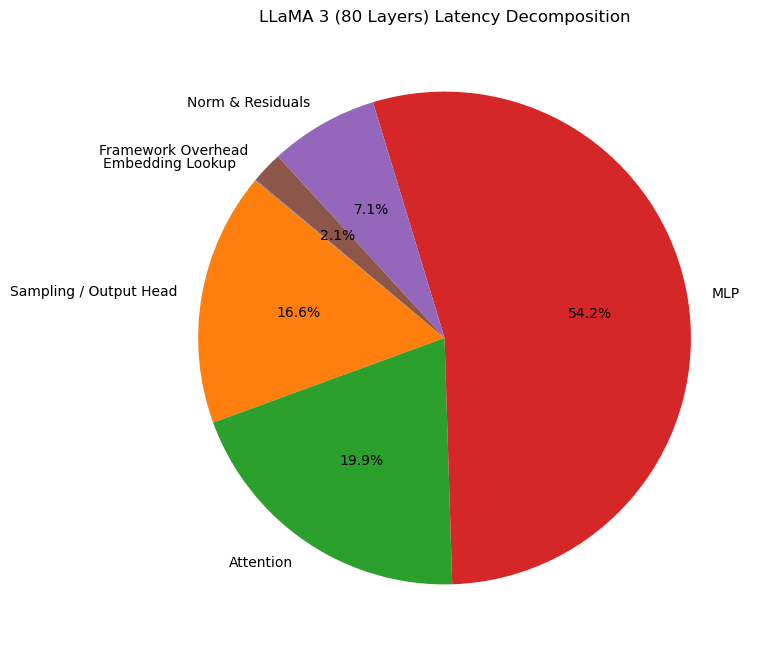

In [18]:
def run_and_plot_goal_2(model, config):
    import matplotlib.pyplot as plt
    model.eval()
    model.reset_timings()
    total_start = time.perf_counter()
    with torch.no_grad():
        token = torch.randint(0, config.vocab_size, (1, 1)).to(config.device)
        logits = model(token)
        _ = torch.argmax(logits[:, -1, :], dim=-1)
        if config.device == "cuda": torch.cuda.synchronize()
    total_wall = time.perf_counter() - total_start
    
    final_data = defaultdict(float)
    final_data['Embedding Lookup'] = model.timings['embedding_lookup']
    final_data['Sampling / Output Head'] = model.timings['output_head']
    for layer in model.layers:
        final_data['Attention'] += layer.timings['attention']
        final_data['MLP'] += layer.timings['mlp']
        final_data['Norm & Residuals'] += layer.timings['layernorm_residuals']

    instr_sum = sum(final_data.values())
    final_data['Framework Overhead'] = max(0, total_wall - instr_sum)

    plt.figure(figsize=(10, 8))
    plt.pie(final_data.values(), labels=final_data.keys(), 
            autopct=lambda p: f'{p:.1f}%' if p >= 2 else '', startangle=140)
    plt.title(f'LLaMA 3 (80 Layers) Latency Decomposition')
    plt.show()

run_and_plot_goal_2(model, config)

Starting Benchmark: 1 warmups, 2 trials...

--- Trial 1 ---
Prefill (TTFT): 206.26ms
  > Token 1: 21.66ms
  > Token 2: 20.30ms
  > Token 3: 19.31ms
  > Token 4: 19.57ms
  > Token 5: 19.39ms
Trial Average Token Latency: 20.05ms

--- Trial 2 ---
Prefill (TTFT): 215.70ms
  > Token 1: 20.65ms
  > Token 2: 21.12ms
  > Token 3: 20.24ms
  > Token 4: 20.24ms
  > Token 5: 24.52ms
Trial Average Token Latency: 21.35ms

Starting Benchmark: 1 warmups, 2 trials...

--- Trial 1 ---
Prefill (TTFT): 373.59ms
  > Token 1: 20.15ms
  > Token 2: 19.43ms
  > Token 3: 18.72ms
  > Token 4: 18.55ms
  > Token 5: 18.55ms
Trial Average Token Latency: 19.08ms

--- Trial 2 ---
Prefill (TTFT): 397.27ms
  > Token 1: 26.81ms
  > Token 2: 22.08ms
  > Token 3: 24.02ms
  > Token 4: 19.71ms
  > Token 5: 19.75ms
Trial Average Token Latency: 22.47ms

Starting Benchmark: 1 warmups, 2 trials...

--- Trial 1 ---
Prefill (TTFT): 859.06ms
  > Token 1: 21.86ms
  > Token 2: 23.24ms
  > Token 3: 22.07ms
  > Token 4: 23.12ms
  > Tok

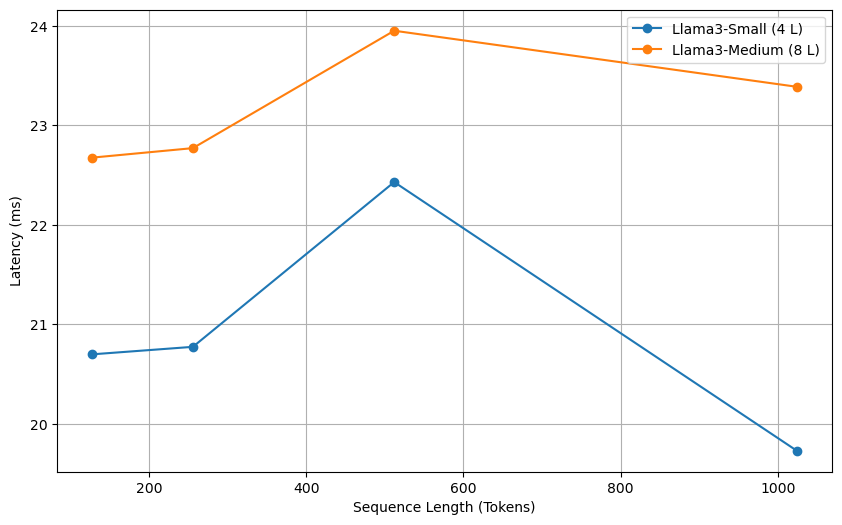

In [20]:
import matplotlib.pyplot as plt

def run_goal_3_scaling():
    variants = {"Llama3-Small (4 L)": 4, "Llama3-Medium (8 L)": 8}
    seq_lengths = [128, 256, 512, 1024]
    results = defaultdict(list)

    for name, layer_count in variants.items():
        v_config = Llama3Config(n_layer=layer_count, n_embd=512)
        v_model = Llama3Model(v_config).to(v_config.device)
        for length in seq_lengths:
            test_prompt = torch.randint(0, v_config.vocab_size, (1, length)).to(v_config.device)
            metrics = benchmark_goal_1_detailed(v_model, test_prompt, warmups=1, trials=2, gen_length=5)
            results[name].append(metrics["Per-Token Steady-State (ms)"])

    plt.figure(figsize=(10, 6))
    for name, latencies in results.items():
        plt.plot(seq_lengths, latencies, marker='o', label=name)
    plt.xlabel('Sequence Length (Tokens)'); plt.ylabel('Latency (ms)'); plt.legend(); plt.grid(True)
    plt.show()

run_goal_3_scaling()

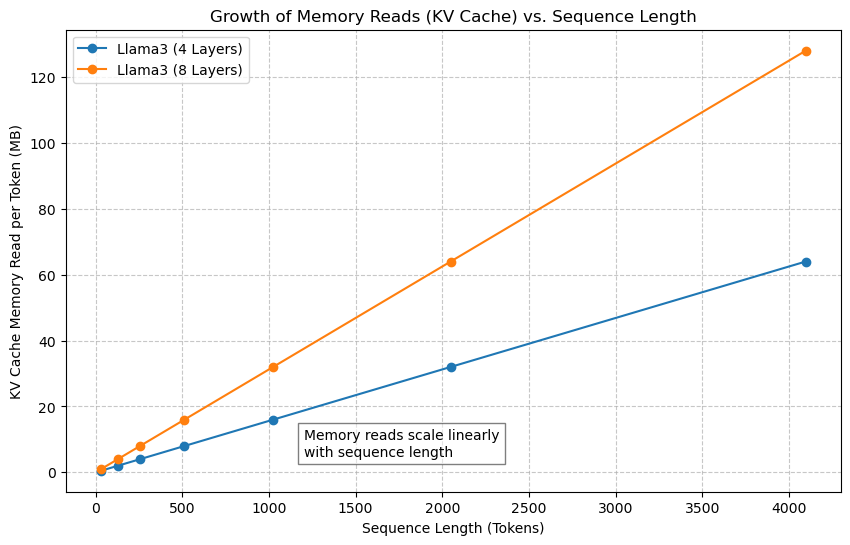

In [21]:
import matplotlib.pyplot as plt
import numpy as np

def plot_memory_scaling():
    n_embd = 4096
    n_head = 32
    n_kv_head = 8
    head_dim = n_embd // n_head # 128
    bytes_per_param = 2 
    
    layers = [4, 8]
    seq_lengths = np.array([32, 128, 256, 512, 1024, 2048, 4096])

    plt.figure(figsize=(10, 6))

    for n_layer in layers:
        memory_reads_mb = (2 * n_layer * n_kv_head * head_dim * seq_lengths * bytes_per_param) / (1024**2)
        
        plt.plot(seq_lengths, memory_reads_mb, marker='o', label=f'Llama3 ({n_layer} Layers)')

    plt.xlabel('Sequence Length (Tokens)')
    plt.ylabel('KV Cache Memory Read per Token (MB)')
    plt.title('Growth of Memory Reads (KV Cache) vs. Sequence Length')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.text(1200, 5, 'Memory reads scale linearly\nwith sequence length', 
             fontsize=10, bbox=dict(facecolor='white', alpha=0.5))
    
    plt.savefig('memory_scaling_graph.png')
    plt.show()

plot_memory_scaling()